In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/air-quality-data-set")
print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/air-quality-data-set


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [5]:
import kagglehub
import os

# Step 1: Download the dataset
dataset_path = kagglehub.dataset_download("fedesoriano/air-quality-data-set")

# Step 2: Check the contents of the downloaded directory
print("Downloaded dataset path:", dataset_path)
print("Contents of the dataset directory:")
print(os.listdir(dataset_path))


Downloaded dataset path: /kaggle/input/air-quality-data-set
Contents of the dataset directory:
['AirQuality.csv']


In [6]:
import pandas as pd

# Step 3: Load the dataset
data_path = '/kaggle/input/air-quality-data-set/AirQuality.csv'
df = pd.read_csv(data_path, sep=';', decimal=',', usecols=lambda col: 'Unnamed' not in col)

# Step 4: Preview the first few rows of the dataset
df.head()


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


Missing values before preprocessing:
Date             114
Time             114
CO(GT)           114
PT08.S1(CO)      114
NMHC(GT)         114
C6H6(GT)         114
PT08.S2(NMHC)    114
NOx(GT)          114
PT08.S3(NOx)     114
NO2(GT)          114
PT08.S4(NO2)     114
PT08.S5(O3)      114
T                114
RH               114
AH               114
dtype: int64
Missing values after preprocessing:
Date             114
Time             114
CO(GT)             0
PT08.S1(CO)        0
NMHC(GT)           0
C6H6(GT)           0
PT08.S2(NMHC)      0
NOx(GT)            0
PT08.S3(NOx)       0
NO2(GT)            0
PT08.S4(NO2)       0
PT08.S5(O3)        0
T                  0
RH                 0
AH                 0
dtype: int64
Mean Squared Error: 2134.2465082449967
R^2 Score: 0.6164750928644931


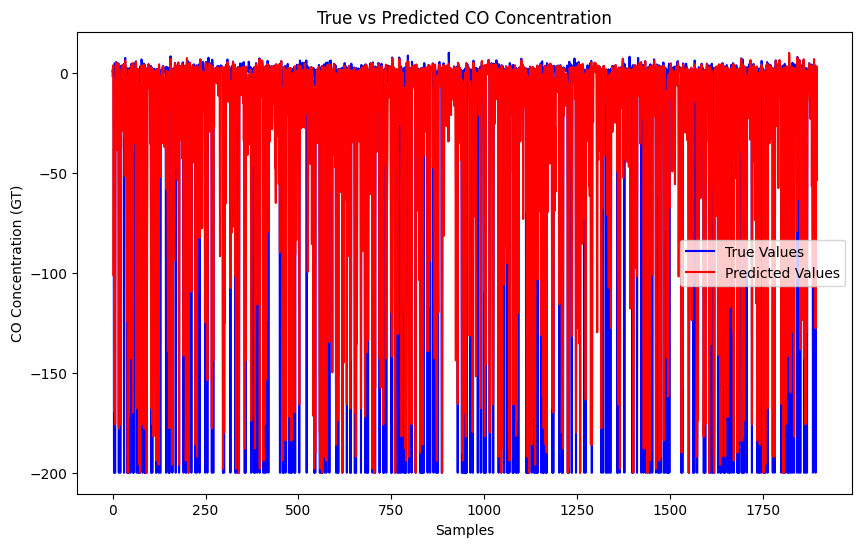

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Load the dataset
data_path = '/kaggle/input/air-quality-data-set/AirQuality.csv'
df = pd.read_csv(data_path, sep=';', decimal=',', usecols=lambda col: 'Unnamed' not in col)

# Step 2: Data Preprocessing
# Check for missing values
print("Missing values before preprocessing:")
print(df.isnull().sum())

# Handle missing values - Only fill missing values for numeric columns
numeric_columns = df.select_dtypes(include=['number']).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# Check again for missing values after filling
print("Missing values after preprocessing:")
print(df.isnull().sum())

# Step 3: Feature Selection
# Drop any columns that are not relevant or have too many missing values
df.drop(columns=['Date', 'Time'], inplace=True)

# Step 4: Split the dataset into features (X) and target (y)
# Let's assume we are trying to predict the concentration of CO (Carbon Monoxide)
X = df.drop(columns=['CO(GT)'])
y = df['CO(GT)']

# Step 5: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Feature Scaling (Normalize the data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: Model Training - Using Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 8: Predictions
y_pred = model.predict(X_test)

# Step 9: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

# Step 10: Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='True Values', color='blue')
plt.plot(y_pred, label='Predicted Values', color='red')
plt.title('True vs Predicted CO Concentration')
plt.xlabel('Samples')
plt.ylabel('CO Concentration (GT)')
plt.legend()
plt.show()



In [4]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Define the model
rf_model = RandomForestRegressor(random_state=42)

# Step 2: Define the hyperparameters grid
param_dist = {
    'n_estimators': [50, 100, 150, 200, 250],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None],  # Removed 'auto'
    'bootstrap': [True, False]
}

# Step 3: Set up RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dist,
                                   n_iter=10, cv=5, n_jobs=-1, random_state=42,
                                   scoring='neg_mean_squared_error', verbose=2)

# Step 4: Fit the random search
random_search.fit(X_train, y_train)

# Step 5: Get the best parameters and best model
best_params = random_search.best_params_
best_model = random_search.best_estimator_

print("Best Hyperparameters:", best_params)

# Step 6: Evaluate the model
y_pred = best_model.predict(X_test)

# Calculate MSE and R^2 score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Hyperparameters: {'n_estimators': 250, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}
Mean Squared Error: 2066.2099865888454
R^2 Score: 0.6287012816150397


<ipython-input-5-e00be2f0204b>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


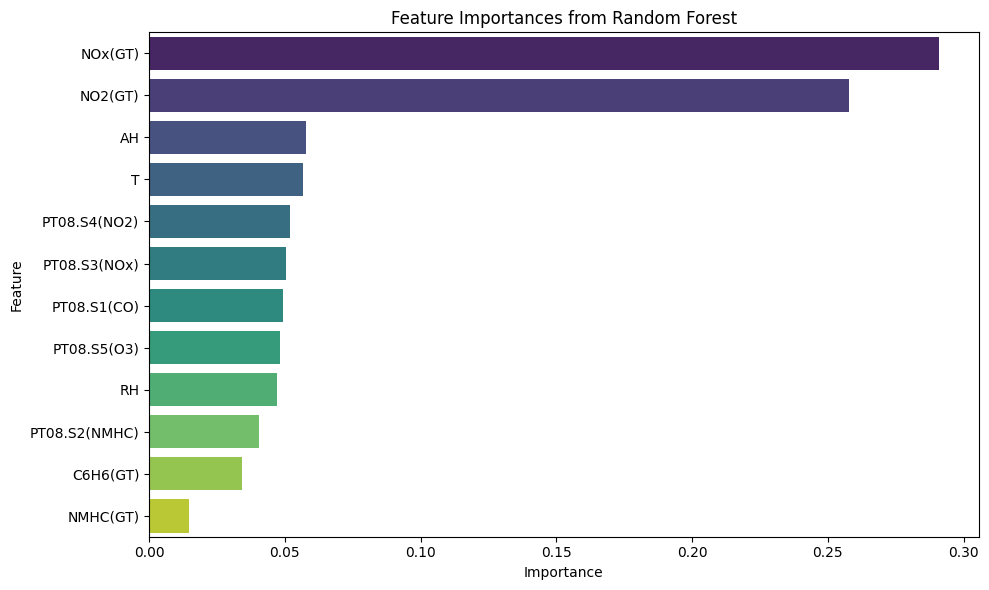

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming "best_model" is your trained RandomForestRegressor
feature_importances = best_model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importances from Random Forest')
plt.tight_layout()
plt.show()